### Intrinsic Method - Random Forest - XXX bootstrap iterations

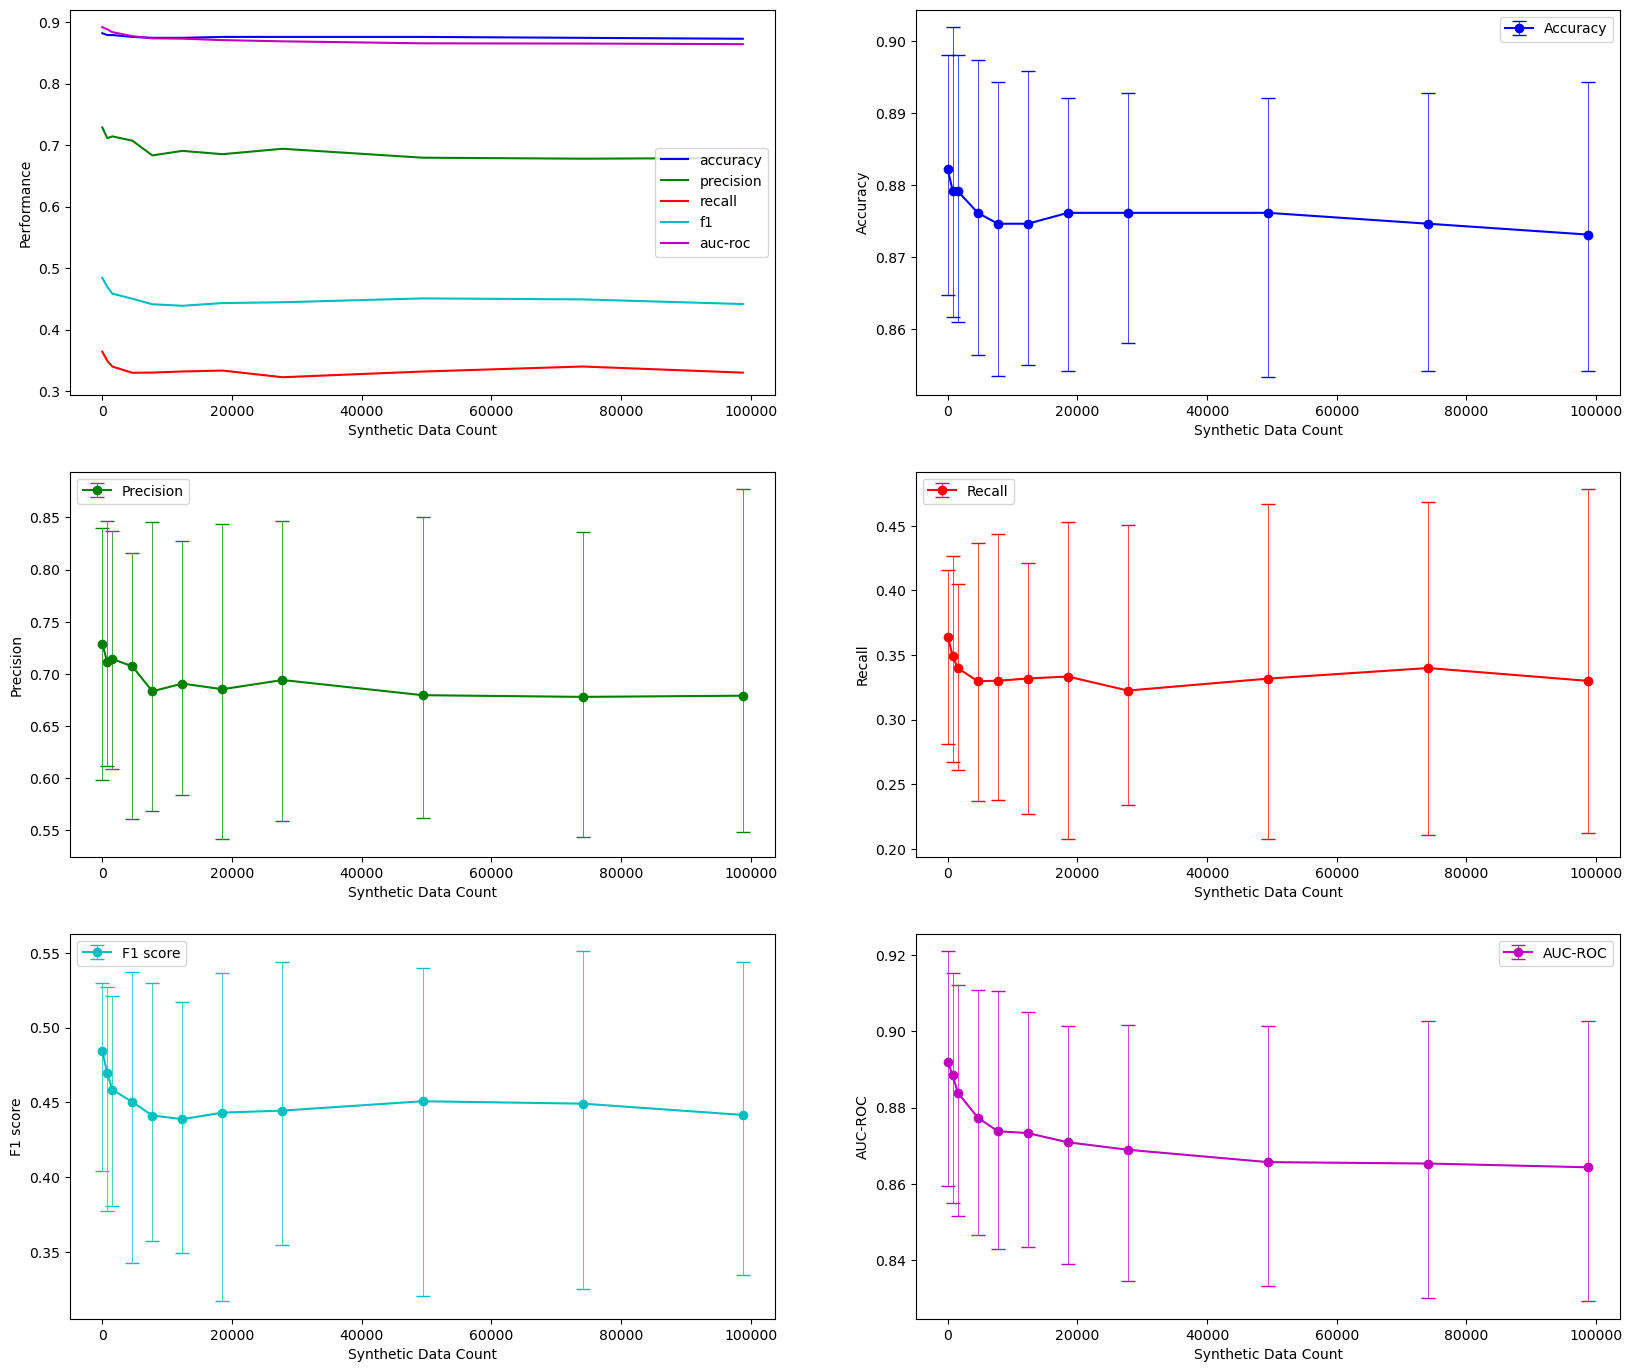

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#intrinsic_rf_bootstrap_vals = pd.read_excel('randomforest_bootstraps_100.xlsx')

#intrinsic_rf_bootstrap_vals = pd.read_excel('intrinsicFAST.xlsx')
#intrinsic_rf_bootstrap_vals = pd.read_excel('instrinisc results 300.xlsx')

intrinsic_rf_bootstrap_vals = pd.read_excel('intrinsic newsamp.xlsx')



# Create a 3x2 grid of subplots
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20,17))  # adjust the size as needed

# Flatten the axes for easier indexing
axes = axes.flatten()


# Calculate average of performance metrics
median_metrics_rf = intrinsic_rf_bootstrap_vals.groupby('syn_size').median().reset_index()
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1 score', 'AUC-ROC']
colors = ['b', 'g', 'r', 'c', 'm']
metrics_list = ['accuracy', 'precision', 'recall', 'f1', 'auc-roc']

# Calculate percentiles
lower_bound = intrinsic_rf_bootstrap_vals.groupby('syn_size').apply(lambda x: x.drop('syn_size', axis=1).quantile(0.025)).reset_index()
upper_bound = intrinsic_rf_bootstrap_vals.groupby('syn_size').apply(lambda x: x.drop('syn_size', axis=1).quantile(0.975)).reset_index()
median_metrics = intrinsic_rf_bootstrap_vals.groupby('syn_size').median().reset_index()


# Calculate average of performance metrics
median_metrics_rf = intrinsic_rf_bootstrap_vals.groupby('syn_size').median().reset_index()

# Plotting the graph on the first axis
for i, metric in enumerate(metrics_list):
    axes[0].plot(median_metrics_rf['syn_size'], median_metrics_rf[metric], color=colors[i], label=metric)
axes[0].set_xlabel('Synthetic Data Count')
axes[0].set_ylabel('Performance')
axes[0].legend(loc='best')

# Move to the next axes for the error bars
for i, metric in enumerate(metrics_list):
    ax = axes[i+1]  # pick the current axis, starting from the second one

    ax.errorbar(median_metrics_rf['syn_size'], median_metrics_rf[metric], 
                yerr=[median_metrics_rf[metric]-lower_bound[metric], upper_bound[metric]-median_metrics_rf[metric]], 
                fmt='o-', color=colors[i], label=metrics_labels[i], elinewidth=0.5, capsize=5)

    ax.set_xlabel('Synthetic Data Count')
    ax.set_ylabel(f'{metrics_labels[i]}')
    ax.legend(loc='best')

# Save the entire figure instead of individual plots
plt.savefig('intrinsiccresultserrors.png', bbox_inches='tight')

# Show the figure with all subplots
plt.show()


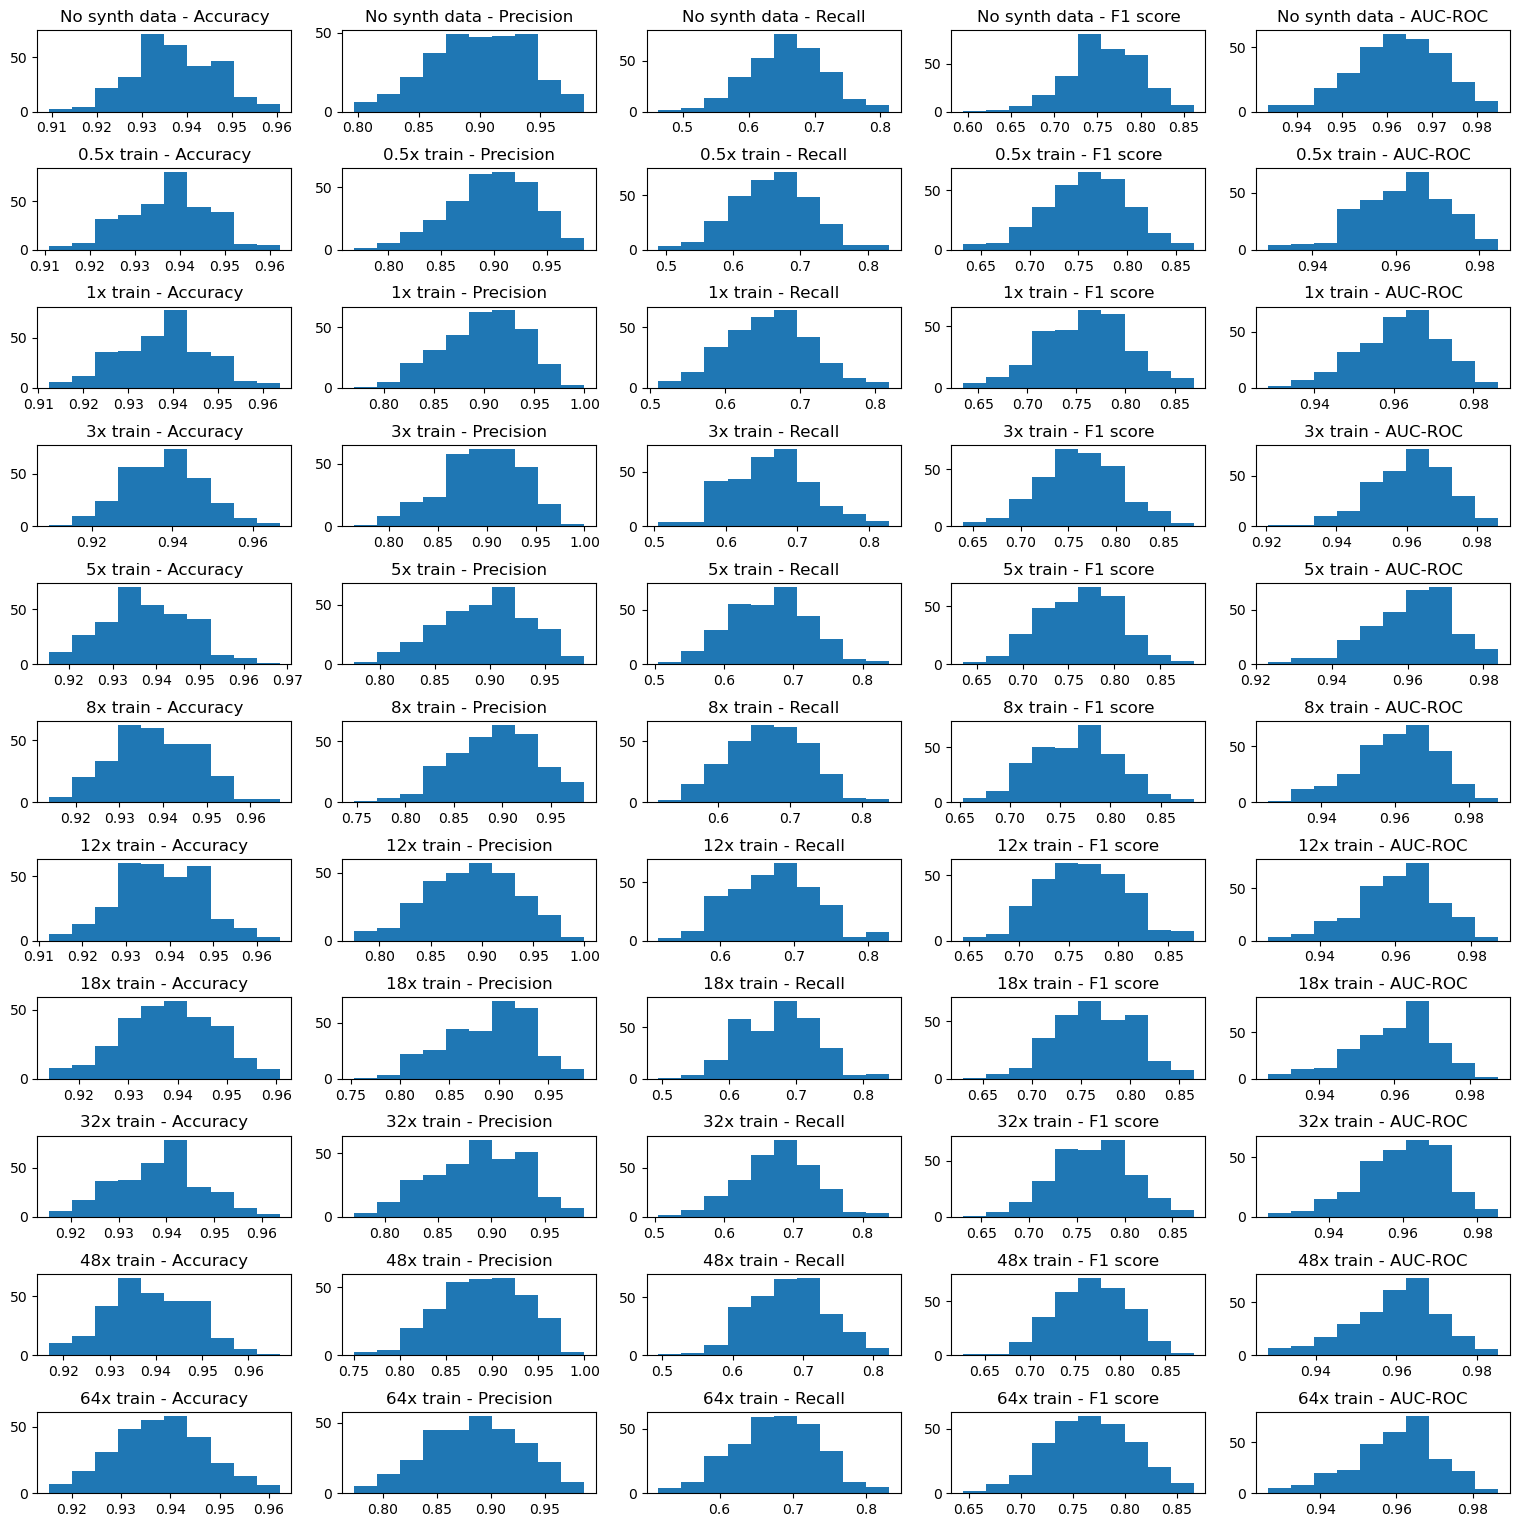

In [6]:

countlen = 1311.975
syn_sizes = [1,771.75, 1543.5, 4630.5, 7717.5, 12348.0, 18522.0,27783.0, 49392.0, 74088.0, 98784.0]
metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc-roc']

#Labels for plots:
syn_sizes_labels = ['No synth data', '0.5x train' , '1x train' , '3x train' , '5x train' 
                    , '8x train' , '12x train' , '18x train' , '32x train','48x train' , '64x train']
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1 score', 'AUC-ROC']

fig, axs = plt.subplots(len(syn_sizes), len(metrics), figsize=(19,19))

grouped = intrinsic_rf_bootstrap_vals.groupby('syn_size')

for i, syn_size in enumerate(syn_sizes):
    group_df = grouped.get_group(syn_size).drop('syn_size', axis=1)
    for j, metric in enumerate(metrics):
        axs[i, j].hist(group_df[metric], bins=10)
        axs[i, j].set_title(f'{syn_sizes_labels[i]} - {metrics_labels[j]}')

plt.subplots_adjust(hspace=0.7)
plt.savefig('bootstrapdistintrinsic.png',bbox_inches='tight')

plt.show()
